# Ejercicio 1

## 1.1 Ejecutar y analizar el código

In [789]:
import tensorflow as tf
print("¿Ejecutando en modo eager?", tf.executing_eagerly())

¿Ejecutando en modo eager? True


Ejecute y analice el siguiente código

In [790]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np
import matplotlib.pyplot as plt
import math
import datetime

In [791]:
# constantes
LAG = 12  # lagged values
HIDDEN1 = 64  # Nro. neuronas de la primera capa
HIDDEN2 = 64
HIDDEN3 = 32
HIDDEN4 = 32
EPOCHS = 200  # número de epocas para entrenamiento


In [792]:
# df = pd.read_csv("Natural_Gas_Spot_Price.csv", index_col=0, parse_dates=[0])
df = pd.read_csv("monthly-milk-production-pounds.csv", index_col=0, parse_dates=[0])
df.columns = ["produccion mensual"]
df.head(20)

,produccion mensual
Month,
1962-01-01,589
1962-02-01,561
1962-03-01,640
1962-04-01,656
1962-05-01,727
1962-06-01,697
1962-07-01,640
1962-08-01,599
1962-09-01,568


In [793]:
df.describe()

,produccion mensual
count,168.000000
mean,754.708333
std,102.204524
min,553.000000
25%,677.750000
50%,761.000000
75%,824.500000
max,969.000000


### Descripción gráfica del dataset

<Axes: xlabel='Month'>

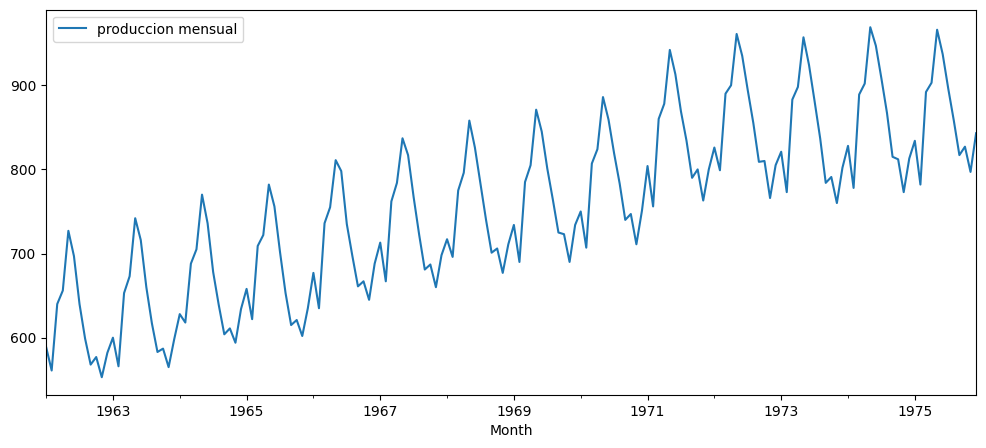

In [794]:
fig, ax = plt.subplots(1, 1, figsize=(12, 5))
df.plot(ax=ax)

### Descomponiendo la serie de tiempo en trend+seasonal+resid

Text(0, 0.5, 'Residuos')

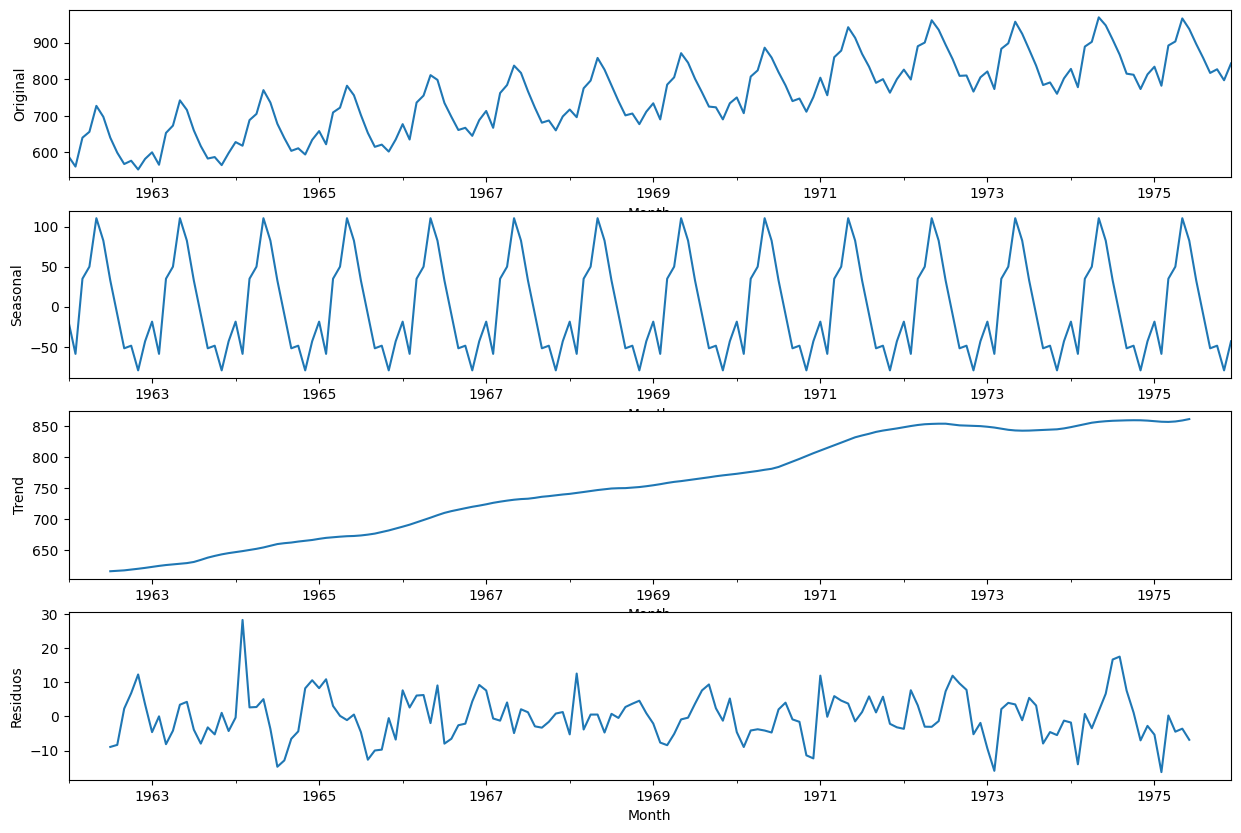

In [795]:
from statsmodels.tsa.seasonal import seasonal_decompose
from matplotlib import pyplot
result = seasonal_decompose(df, model='additive')
# result.plot()
# plt.show()

fig, ax = plt.subplots(4, 1, figsize=(15, 10))
result.observed.plot(ax=ax[0])
ax[0].set_ylabel("Original")
result.seasonal.plot(ax=ax[1])
ax[1].set_ylabel("Seasonal")
result.trend.plot(ax=ax[2])
ax[2].set_ylabel("Trend")
result.resid.plot(ax=ax[3])
ax[3].set_ylabel("Residuos")


<Axes: xlabel='Lag', ylabel='Autocorrelation'>

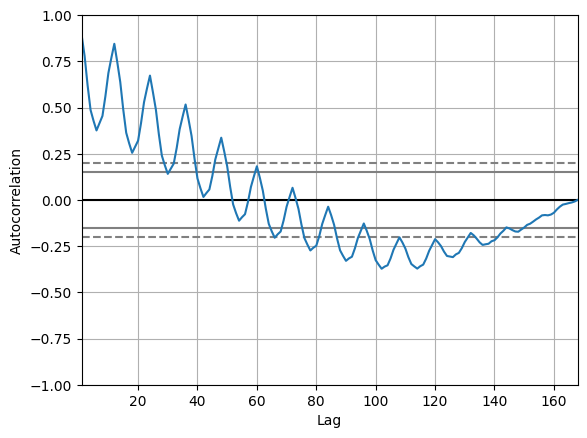

In [796]:
pd.plotting.autocorrelation_plot(df)

## Datos para entrenamiento y prueba

In [797]:
train_data = df[:'1974-12-31']
test_data  = df['1975-01-01':]

print('Observations: %d' % (len(df)))
print('Train Dataset:',train_data.shape)
print('Test Dataset:', test_data.shape)

Observations: 168
Train Dataset: (156, 1)
Test Dataset: (12, 1)


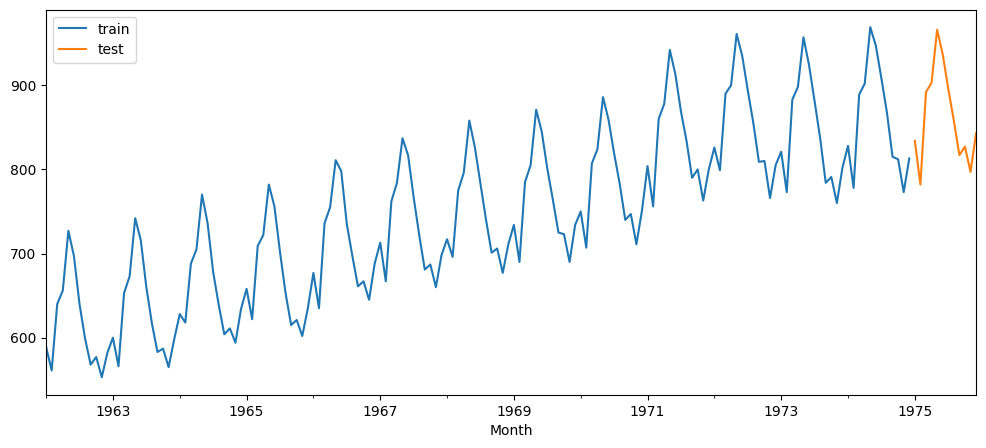

In [798]:
fig, ax = plt.subplots(1, 1, figsize=(12, 5))
train_data.plot(ax=ax)
test_data.plot(ax=ax)
plt.legend(['train', 'test']);

### Normalizando y dividiendo los datos para entrenamiento y prueba

In [799]:
from sklearn.preprocessing import MinMaxScaler

# los datos son escalados en un rango de 0 y 1
scaler = MinMaxScaler(feature_range=(0,1))

train_data_scaled = scaler.fit_transform(train_data)
test_data_scaled = scaler.transform(test_data)

In [800]:
# se actualiza el valor del dataframe con los valores normalizados
df['produccion mensual'] = np.concatenate([train_data_scaled, test_data_scaled])[:, 0]

In [801]:
def window(ds, lags):
    tmp_ind = ds.index.to_numpy()[lags:]
    for i in range(lags):
        tmp = ds.iloc[:, 0].shift(-(i+1))
        ds = pd.concat([ds, tmp], axis=1)

    ds = ds.dropna()
    ds.index = tmp_ind

    return ds

ndf = window(df, LAG)
train_data_scaled = ndf[:'1974-12-31'].to_numpy()
test_data_scaled  = ndf['1975-01-01':].to_numpy()

In [802]:
print('Observations: %d' % (len(ndf)))
print('Train Dataset:',train_data_scaled.shape)
print('Test Dataset:', test_data_scaled.shape)

Observations: 156
Train Dataset: (144, 13)
Test Dataset: (12, 13)


### Normalizando los datos

In [803]:
# se asignan los datos para entrenamiento y prueba
X_train, y_train = train_data_scaled[:, :-1], train_data_scaled[:, -1]
X_test, y_test = test_data_scaled[:, :-1], test_data_scaled[:, -1]

In [804]:
# reshaping
# 3D tensor with shape (batch_size, timesteps, input_dim).

# Keras adminte datos de entrada del tipo (batch_size, timesteps, input_dim)
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
print(X_train.shape, y_train.shape)

(144, 12, 1) (144,)


## Creando y entrenando el modelo

In [805]:
# Creando el modelo

# initializing RNN
model = tf.keras.Sequential()

# adding 1st LSTM layer and some dropout regularization
model.add(tf.keras.layers.LSTM(units=HIDDEN1, input_shape=(X_train.shape[1], 1), return_sequences=True, activation='relu'))
model.add(tf.keras.layers.Dropout(0.2))

# adding 2nd LSTM layer and some dropout regularization
model.add(tf.keras.layers.LSTM(units=HIDDEN2, return_sequences=True))
model.add(tf.keras.layers.Dropout(0.2))

# adding 3rd LSTM layer and some dropout regularization
model.add(tf.keras.layers.LSTM(units=HIDDEN3, return_sequences=True))
model.add(tf.keras.layers.Dropout(0.2))

# adding 4th LSTM layer and some dropout regularization
model.add(tf.keras.layers.LSTM(units=HIDDEN4))
model.add(tf.keras.layers.Dropout(0.2))

# adding output layer
model.add(tf.keras.layers.Dense(units=1))

#compiling RNN
model.compile(loss='mean_squared_error', optimizer='adam')
#model.compile(loss='mean_absolute_percentage_error', optimizer='adam')

early_stopping = EarlyStopping(monitor='val_loss', patience=10)

# fitting RNN on training set
history = model.fit(X_train, y_train,
                    epochs=EPOCHS,
                    batch_size=32,
                    validation_split=0.2,
                    verbose=2,
                    callbacks=[early_stopping])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/200
4/4 - 8s - 2s/step - loss: 0.2090 - val_loss: 0.3256
Epoch 2/200
4/4 - 0s - 51ms/step - loss: 0.1138 - val_loss: 0.0977
Epoch 3/200
4/4 - 0s - 47ms/step - loss: 0.0369 - val_loss: 0.0410
Epoch 4/200
4/4 - 0s - 52ms/step - loss: 0.0591 - val_loss: 0.0229
Epoch 5/200
4/4 - 0s - 52ms/step - loss: 0.0378 - val_loss: 0.0664
Epoch 6/200
4/4 - 0s - 63ms/step - loss: 0.0410 - val_loss: 0.0760
Epoch 7/200
4/4 - 0s - 48ms/step - loss: 0.0358 - val_loss: 0.0449
Epoch 8/200
4/4 - 0s - 49ms/step - loss: 0.0303 - val_loss: 0.0227
Epoch 9/200
4/4 - 0s - 54ms/step - loss: 0.0347 - val_loss: 0.0213
Epoch 10/200
4/4 - 0s - 49ms/step - loss: 0.0315 - val_loss: 0.0296
Epoch 11/200
4/4 - 0s - 51ms/step - loss: 0.0304 - val_loss: 0.0362
Epoch 12/200
4/4 - 0s - 48ms/step - loss: 0.0269 - val_loss: 0.0235
Epoch 13/200
4/4 - 0s - 49ms/step - loss: 0.0240 - val_loss: 0.0211
Epoch 14/200
4/4 - 0s - 75ms/step - loss: 0.0271 - val_loss: 0.0204
Epoch 15/200
4/4 - 0s - 47ms/step - loss: 0.0200 - val_loss

In [806]:
# cambia la forma del vector de prueba para que sea aceptado por el modelo
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

# predice con las matrices de entrenamiento y prueba
trainPredict = model.predict(X_train)
testPredict = model.predict(X_test)

# invert predictions
trainPredict = scaler.inverse_transform(trainPredict)
trainY = scaler.inverse_transform([y_train])
testPredict = scaler.inverse_transform(testPredict)
testY = scaler.inverse_transform([y_test])

# calcula root mean squared error
trainScore = math.sqrt(mean_squared_error(trainY[0], trainPredict[:,0]))
print('Train Score: %.2f RMSE' % (trainScore))

testScore = math.sqrt(mean_squared_error(testY[0], testPredict[:,0]))
print('Test Score: %.2f RMSE' % (testScore))

# calcula el r2
trainScore = r2_score(trainY[0], trainPredict[:,0])
print('Train Score: %.2f R2' % (trainScore))

testScore = r2_score(testY[0], testPredict[:,0])
print('Test Score: %.2f R2' % (testScore))

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 153ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Train Score: 35.09 RMSE
Test Score: 42.27 RMSE
Train Score: 0.86 R2
Test Score: 0.39 R2


In [807]:
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100


trainScoreMape = mean_absolute_percentage_error(trainY[0], trainPredict[:,0])
print('Train Score: %.2f Mape' % (trainScoreMape))

testScoreMape = mean_absolute_percentage_error(testY[0], testPredict[:,0])
print('Test Score: %.2f Mape' % (testScoreMape))

Train Score: 3.74 Mape
Test Score: 4.09 Mape


### Resultados de la predicción

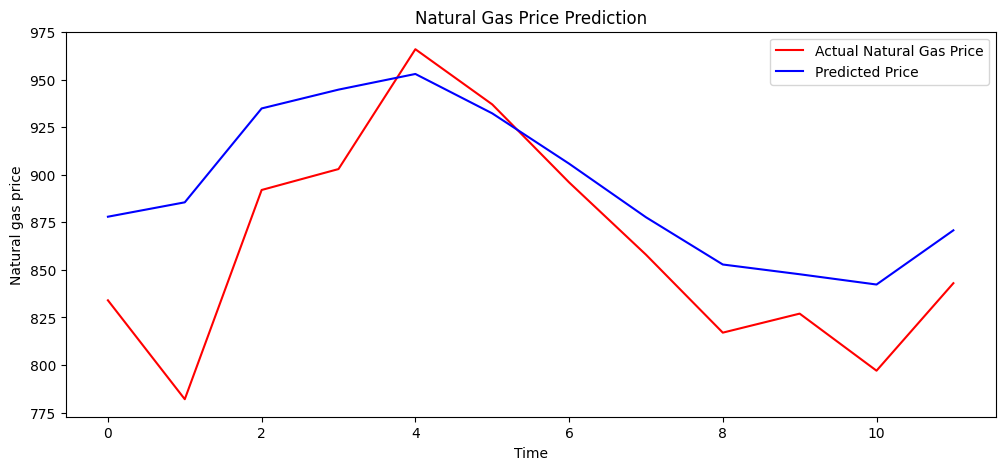

In [808]:
fig, ax = plt.subplots(1, 1, figsize=(12, 5))

ax.plot(testY[0], color = 'red', label ="Actual Natural Gas Price")
ax.plot(testPredict, color='blue', label = 'Predicted Price')
plt.title("Natural Gas Price Prediction")
plt.xlabel('Time')
plt.ylabel('Natural gas price')
plt.legend(loc='best')
plt.show()

### Resultados del entrenamiento

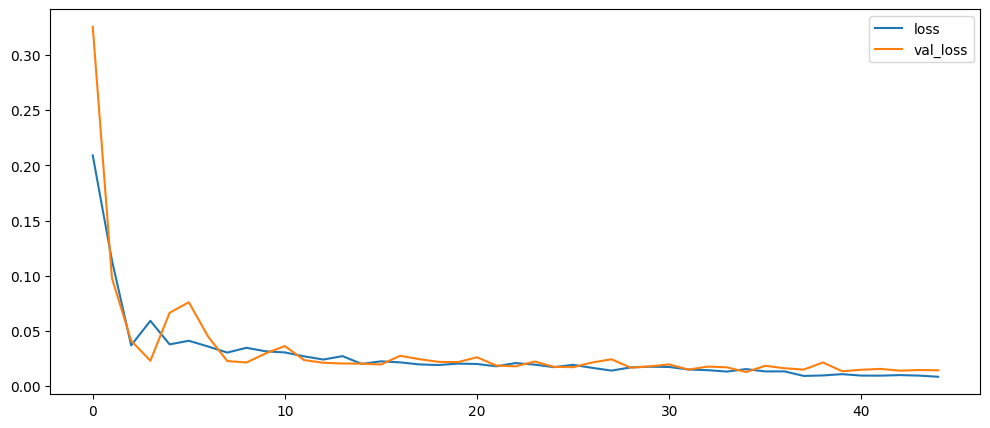

In [809]:
fig, ax = plt.subplots(1, 1, figsize=(12, 5))
ax.plot(history.history["loss"], label="loss")
ax.plot(history.history["val_loss"], label="val_loss")
plt.legend()
plt.show()

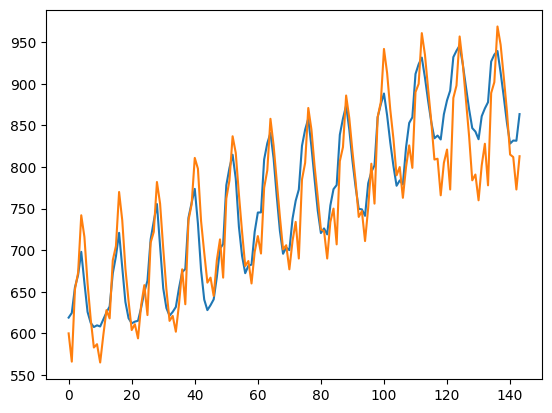

In [810]:
plt.plot(trainPredict[:, 0])
plt.plot(scaler.inverse_transform([y_train])[0, :])

##